Loading master flat CSV: /home/hello/Projects/Statements/output/moltie_all/MASTER_moltie_flat.csv
Total rows loaded: 42618
Total columns: 31
Rows after drop_duplicates(): 42618 (removed 0)
Relevant rows: 11701
Relevant ET cases: 2578

=== X ARGUMENT FREQUENCY ===


/tmp/ipykernel_76306/2160268619.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


x_name
Inconsistent Explanations                       1222
First Presentation of Allegations               1194
Proportionality of Dismissal                    1145
Inconsistent and Unreasonable Reasoning         1066
Failure to Provide Timely Resolution            1057
Lack of Genuine Reconsideration                  971
Lack of Prior Notice of Disciplinary Meeting     705
Failure to Reconcile Conclusions with Data       558
Lack of Corrective Guidance                      516
Lack of Written Instructions                     391
Reliance on Unsupported Oral Recall              386
Management Expectations                          347
Factual Basis for Allegations                    343
Contextual Evidence of Procedural Failures       279
Lack of Fair and Open-Minded Process             255
Failure to Address Internal Dissemination        169
Predetermination Evidence                        151
Comparator Evidence                              118
Excessive Workload Without Adjustment  


=== NEEDLE FREQUENCY ===


matched_needles
has__assumed_intention_regex        9482
has__appeal_scope_regex             1385
has__predetermination                512
has__no_contemporaneous_evidence     406
GENERAL                              230
Name: count, dtype: int64

...

successful_party
claimant      4443
respondent    4071
unclear       3187
Name: count, dtype: int64


=== PRECEDENT SCORE ===


count    11701.000000
mean        67.721135
std          5.699446
min          5.000000
25%         60.000000
50%         70.000000
75%         70.000000
max         80.000000
Name: precedent_score, dtype: float64


=== TOP PRECEDENT MATCHES ===


,x_name,et_filename,precedent_score,confidence,anchor_count,matched_needles
1997,Inconsistent Explanations,Miss_P_Marapara_v_Barnet__Enfield_and_Haringey...,80.0,90.0,3,"['has__assumed_intention_regex', 'has__no_cont..."
28924,Proportionality of Dismissal,Mr_D_Coelho_v_Colchester_Hospital_University_N...,80.0,80.0,3,['has__assumed_intention_regex']
30323,Lack of Fair and Open-Minded Process,Dr_G_Richardson_v_University_Hospitals_Leicest...,80.0,80.0,3,['has__appeal_scope_regex']
34104,Proportionality of Dismissal,Mrs_H_Todd_v_1._Shaun_Collins_2._52_Street_Eve...,80.0,80.0,2,['has__assumed_intention_regex']
38461,Proportionality of Dismissal,Mr_Tamunoemi_Amachree_-v-_Royal_Mail_Group_Lim...,80.0,80.0,2,['has__assumed_intention_regex']
32297,Proportionality of Dismissal,2500047-17_barker_jjlh_dcb_ResJR_04-07-17__FIN...,80.0,80.0,2,['has__assumed_intention_regex']
5363,Lack of Written Instructions,Mr_L_Hannagan_v_DNXB_Group_Ltd_2301453-2020_Fu...,80.0,80.0,2,['has__assumed_intention_regex']
29900,Lack of Fair and Open-Minded Process,Mr_R_Aford_v_Manchester_Breakdown_Services_Lim...,80.0,80.0,3,['has__appeal_scope_regex']
29377,Lack of Fair and Open-Minded Process,Mr_N_Asokkumar_v_Canary_Wharf_Management_Ltd_3...,80.0,80.0,3,['has__appeal_scope_regex']
12673,Failure to Reconcile Conclusions with Data,Mr_D_Carter_v_Royal_Mail_Group_Limited_1400881...,80.0,80.0,2,['has__assumed_intention_regex']


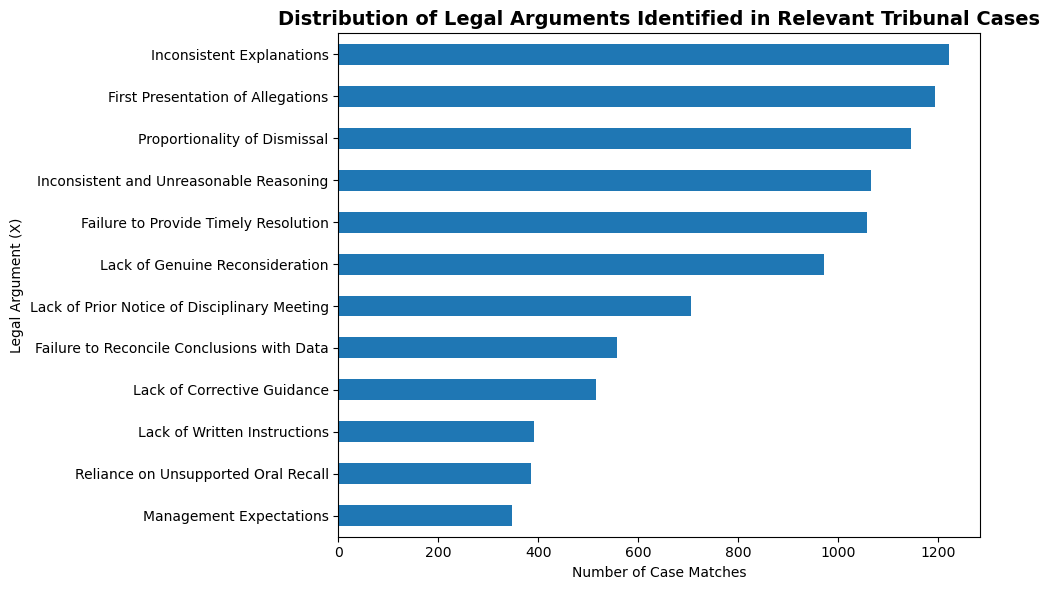

In [3]:
# =========================================================
# CELL 1 — FLAT MOLTIE CSV ANALYTICS (RELEVANT ONLY)
# =========================================================

import ast
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt

# ---------------------------------------------------------
# MASTER FILE
# ---------------------------------------------------------

MASTER_FLAT_CSV = Path("/home/hello/Projects/Statements/output/moltie_all/MASTER_moltie_flat.csv")

if not MASTER_FLAT_CSV.exists():
    raise FileNotFoundError(f"Master flat CSV not found: {MASTER_FLAT_CSV}")

# ---------------------------------------------------------
# LOAD MASTER
# ---------------------------------------------------------

print(f"Loading master flat CSV: {MASTER_FLAT_CSV}")
flat_df = pd.read_csv(MASTER_FLAT_CSV)

print("Total rows loaded:", len(flat_df))
print("Total columns:", len(flat_df.columns))

# ---------------------------------------------------------
# OPTIONAL DEDUP
# ---------------------------------------------------------

before_dedup = len(flat_df)
flat_df = flat_df.drop_duplicates().copy()
after_dedup = len(flat_df)

print(f"Rows after drop_duplicates(): {after_dedup} (removed {before_dedup - after_dedup})")

# ---------------------------------------------------------
# NORMALISE RELEVANT FLAG
# ---------------------------------------------------------

def normalize_bool_like(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({
            "true": True,
            "1": True,
            "yes": True,
            "y": True,
            "false": False,
            "0": False,
            "no": False,
            "n": False,
        })
        .fillna(False)
    )

if "relevant" not in flat_df.columns:
    raise KeyError("Column 'relevant' not found in master flat CSV.")

flat_df["relevant_norm"] = normalize_bool_like(flat_df["relevant"])

# ---------------------------------------------------------
# FILTER TO RELEVANT ONLY
# ---------------------------------------------------------

relevant_df = flat_df[flat_df["relevant_norm"]].copy()

print("Relevant rows:", len(relevant_df))

if "et_path" in relevant_df.columns:
    print("Relevant ET cases:", relevant_df["et_path"].nunique())
elif "et_filename" in relevant_df.columns:
    print("Relevant ET cases:", relevant_df["et_filename"].nunique())
else:
    print("Relevant ET cases: could not compute (missing both 'et_path' and 'et_filename').")

# ---------------------------------------------------------
# X ARGUMENT FREQUENCY
# ---------------------------------------------------------

print("\n=== X ARGUMENT FREQUENCY ===")
if "x_name" in relevant_df.columns:
    display(relevant_df["x_name"].fillna("<<MISSING>>").value_counts().head(20))
else:
    print("Column 'x_name' not found.")

# ---------------------------------------------------------
# NEEDLE PARSER
# ---------------------------------------------------------

def parse_needles_cell(cell):
    if pd.isna(cell):
        return []
    
    if isinstance(cell, list):
        return [str(x).strip() for x in cell if str(x).strip()]
    
    text = str(cell).strip()
    if not text:
        return []
    
    # Try proper Python-list parsing first
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(x).strip() for x in parsed if str(x).strip()]
    except Exception:
        pass
    
    # Fallback: loose comma split after removing brackets
    text = text.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
    return [x.strip() for x in text.split(",") if x.strip()]

# ---------------------------------------------------------
# NEEDLE FREQUENCY
# ---------------------------------------------------------

print("\n=== NEEDLE FREQUENCY ===")
if "matched_needles" in relevant_df.columns:
    needle_freq = (
        relevant_df["matched_needles"]
        .apply(parse_needles_cell)
        .explode()
        .dropna()
        .astype(str)
        .str.strip()
    )
    
    needle_freq = needle_freq[needle_freq != ""].value_counts()
    display(needle_freq.head(20))
else:
    print("Column 'matched_needles' not found.")

# ---------------------------------------------------------
# APPEAL OUTCOME
# ---------------------------------------------------------

print("\n=== APPEAL OUTCOME ===")
if "appeal_outcome" in relevant_df.columns:
    display(relevant_df["appeal_outcome"].fillna("<<MISSING>>").value_counts())
else:
    print("Column 'appeal_outcome' not found.")

# ---------------------------------------------------------
# SUCCESSFUL PARTY
# ---------------------------------------------------------

print("\n=== SUCCESSFUL PARTY ===")
if "successful_party" in relevant_df.columns:
    display(relevant_df["successful_party"].fillna("<<MISSING>>").value_counts())
else:
    print("Column 'successful_party' not found.")

# ---------------------------------------------------------
# PRECEDENT SCORE
# ---------------------------------------------------------

print("\n=== PRECEDENT SCORE ===")
if "precedent_score" in relevant_df.columns:
    relevant_df["precedent_score"] = pd.to_numeric(relevant_df["precedent_score"], errors="coerce")
    display(relevant_df["precedent_score"].describe())
else:
    print("Column 'precedent_score' not found.")

# ---------------------------------------------------------
# TOP PRECEDENT MATCHES
# ---------------------------------------------------------

print("\n=== TOP PRECEDENT MATCHES ===")

top_cols = [
    "x_name",
    "et_filename",
    "precedent_score",
    "confidence",
    "anchor_count",
    "matched_needles"
]
top_cols_existing = [c for c in top_cols if c in relevant_df.columns]

if "precedent_score" in relevant_df.columns and top_cols_existing:
    display(
        relevant_df
        .sort_values("precedent_score", ascending=False, na_position="last")
        .head(20)[top_cols_existing]
    )
else:
    print("Could not compute top precedent matches (missing required columns).")

# ---------------------------------------------------------
# ARGUMENT DISTRIBUTION
# ---------------------------------------------------------

if "x_name" in relevant_df.columns:
    arg_dist = (
        relevant_df["x_name"]
        .fillna("<<MISSING>>")
        .value_counts()
        .head(12)
        .sort_values()
    )

    # ---------------------------------------------------------
    # CHART
    # ---------------------------------------------------------

    plt.figure(figsize=(10, 6))
    arg_dist.plot(kind="barh")

    plt.title(
        "Distribution of Legal Arguments Identified in Relevant Tribunal Cases",
        fontsize=14,
        weight="bold"
    )
    plt.xlabel("Number of Case Matches")
    plt.ylabel("Legal Argument (X)")

    plt.tight_layout()
    plt.show()
else:
    print("Chart skipped: column 'x_name' not found.")

Loading master PDF frequency CSV: /home/hello/Projects/Statements/output/moltie_all/MASTER_moltie_pdf_frequency.csv
Total rows loaded: 4463
Total columns: 15
Relevant ET cases: 4463

=== PRECEDENT STRENGTH ===


count    4463.000000
mean        0.578959
std         0.076569
min         0.352100
25%         0.520200
50%         0.579300
75%         0.629200
max         0.900000
Name: precedent_strength, dtype: float64


=== APPEAL OUTCOME ===


appeal_outcome_pdf
unknown                                  2273
allowed | unknown                         420
unknown | dismissed                       353
dismissed                                 338
dismissed | unknown                       278
allowed                                   269
unknown | allowed                         248
allowed | unknown | dismissed              55
allowed | dismissed                        52
allowed | dismissed | unknown              40
unknown | allowed | dismissed              29
unknown | dismissed | allowed              26
dismissed | allowed | unknown              24
dismissed | allowed                        22
dismissed | unknown | allowed              20
mixed                                       4
mixed | unknown                             1
unknown | allowed | mixed | dismissed       1
allowed | dismissed | mixed | unknown       1
dismissed | unknown | mixed                 1
dismissed | mixed                           1
mixed | allowed


=== SUCCESSFUL PARTY ===


...


=== NEEDLE DISTRIBUTION ===


matched_needles_pdf
has__assumed_intention_regex        3877
has__appeal_scope_regex              255
has__no_contemporaneous_evidence     204
GENERAL                              145
has__predetermination                110
Name: count, dtype: int64


=== STRONGEST PRECEDENT CASES ===


,et_path,precedent_strength,max_anchor_count,max_confidence,max_precedent_score,successful_party_pdf
0,/media/hello/Vault/Tribunals/ET_Cases/Mr_R_Swe...,0.9000,3,80,80,claimant
4412,/media/hello/Vault/Tribunals/ET_Cases/Mr_J_Ald...,0.8833,3,80,80,respondent
4230,/media/hello/Vault/Tribunals/ET_Cases/Mr_D_Why...,0.8833,3,80,80,claimant
1905,/media/hello/Vault/Tribunals/ET_Cases/Mr_L_Por...,0.8435,3,80,80,claimant
2,/media/hello/Vault/Tribunals/ET_Cases/Mr_J_Sam...,0.8312,3,80,80,claimant | unclear
1,/media/hello/Vault/Tribunals/ET_Cases/Miss_R_D...,0.8312,3,80,80,claimant | unclear
4,/media/hello/Vault/Tribunals/ET_Cases/Mrs_J_Pr...,0.8250,3,80,70,claimant
3,/media/hello/Vault/Tribunals/ET_Cases/Millie_D...,0.8250,3,80,80,claimant | unclear
1992,/media/hello/Vault/Tribunals/ET_Cases/Mr_L_Lav...,0.8179,3,80,80,claimant | respondent
5,/media/hello/Vault/Tribunals/ET_Cases/Miss_C_M...,0.8125,3,80,70,claimant


/home/hello/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


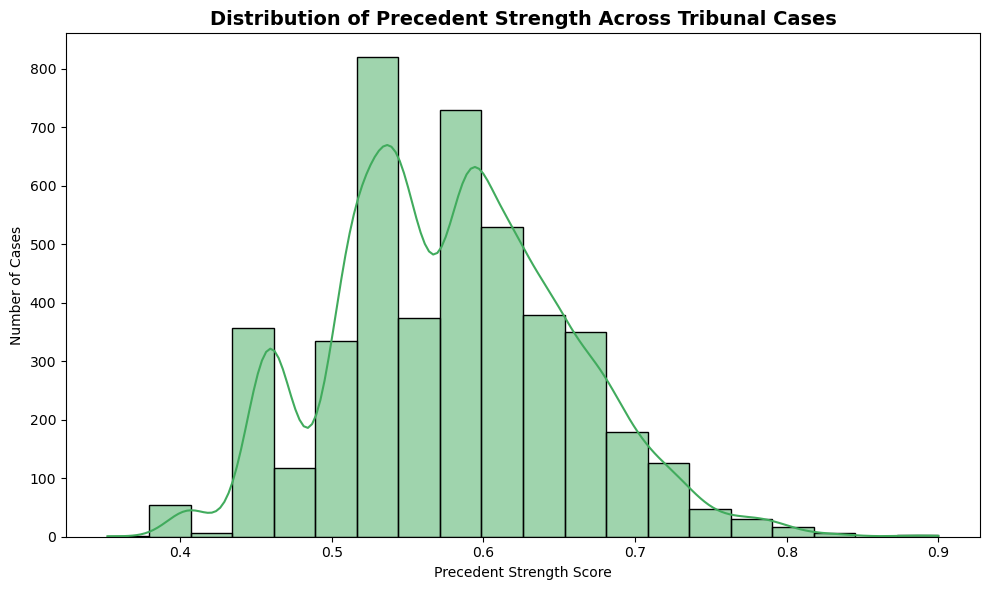

In [4]:
# =========================================================
# CELL 2 — ET CASE ANALYTICS (RELEVANT CASES)
# =========================================================

import pandas as pd
from pathlib import Path
import seaborn as sns


# ---------------------------------------------------------
# LIST FILES
# ---------------------------------------------------------

import pandas as pd
from pathlib import Path

MASTER_PDF_CSV = Path("/home/hello/Projects/Statements/output/moltie_all/MASTER_moltie_pdf_frequency.csv")

if not MASTER_PDF_CSV.exists():
    raise FileNotFoundError(f"Master PDF frequency CSV not found: {MASTER_PDF_CSV}")

# ---------------------------------------------------------
# LOAD MASTER
# ---------------------------------------------------------

print(f"Loading master PDF frequency CSV: {MASTER_PDF_CSV}")
case_df = pd.read_csv(MASTER_PDF_CSV)

print("Total rows loaded:", len(case_df))
print("Total columns:", len(case_df.columns))

# ---------------------------------------------------------
# FILTER: ONLY CASES WITH RELEVANT RUNS
# ---------------------------------------------------------

case_df = case_df[case_df["n_relevant_runs"] > 0].copy()

print("Relevant ET cases:", len(case_df))

# ---------------------------------------------------------
# PRECEDENT STRENGTH
# ---------------------------------------------------------

print("\n=== PRECEDENT STRENGTH ===")
display(case_df["precedent_strength"].describe())

# ---------------------------------------------------------
# APPEAL OUTCOME
# ---------------------------------------------------------

print("\n=== APPEAL OUTCOME ===")
display(case_df["appeal_outcome_pdf"].value_counts())

# ---------------------------------------------------------
# SUCCESSFUL PARTY
# ---------------------------------------------------------

print("\n=== SUCCESSFUL PARTY ===")
display(case_df["successful_party_pdf"].value_counts())

# ---------------------------------------------------------
# NEEDLE DISTRIBUTION
# ---------------------------------------------------------

print("\n=== NEEDLE DISTRIBUTION ===")

needle_freq = (
    case_df["matched_needles_pdf"]
    .dropna()
    .astype(str)
    .str.split("|")
    .explode()
    .str.strip()
    .value_counts()
)

display(needle_freq.head(20))

# ---------------------------------------------------------
# STRONGEST PRECEDENTS
# ---------------------------------------------------------

print("\n=== STRONGEST PRECEDENT CASES ===")

display(
    case_df
    .sort_values("precedent_strength", ascending=False)
    .head(20)[[
        "et_path",
        "precedent_strength",
        "max_anchor_count",
        "max_confidence",
        "max_precedent_score",
        "successful_party_pdf"
    ]]
)

# ---------------------------------------------------------
# CHART
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

sns.histplot(
    case_df["precedent_strength"],
    bins=20,
    kde=True,
    color="#41ab5d"
)

plt.title(
    "Distribution of Precedent Strength Across Tribunal Cases",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Precedent Strength Score")
plt.ylabel("Number of Cases")

plt.tight_layout()
plt.show()

In [8]:
case_df[case_df["successful_party_pdf"] == "claimant"].to_csv("/home/hello/Projects/Statements/output/moltie_all/claimant_wins.csv", index=False)

In [10]:
path = r'/home/hello/Projects/Statements/output/moltie_batch (Y10-Y11-Y12)/MASTER_moltie__pdf_frequency.csv'
df = pd.read_csv(path)      

df

,et_path,n_relevant_runs,max_anchor_count,max_confidence,mean_confidence,max_precedent_score,mean_precedent_score,precedent_strength,matched_needles_pdf,use_mode_pdf,proposition_winner_pdf,appeal_outcome_pdf,successful_party_pdf,x_name_pdf,note_pdf
0,/media/hello/Vault/Tribunals/ET_Cases/Mr_L_Lav...,14,3,80,79,80,74,0.8179,has__appeal_scope_regex | has__assumed_intenti...,support,claimant,allowed | unknown,claimant | respondent,Failure to Provide Timely Resolution | Relianc...,The respondent failed to provide a meaningful ...
1,/media/hello/Vault/Tribunals/ET_Cases/Mr_J_Gla...,13,3,80,79,80,72,0.7966,has__appeal_scope_regex | has__assumed_intenti...,support,respondent | claimant | unclear,dismissed | unknown | allowed,respondent | unclear | claimant,Inconsistent and Unreasonable Reasoning | Reli...,The tribunal found no evidence supporting the ...
2,/media/hello/Vault/Tribunals/ET_Cases/Mr_J_Sam...,12,3,80,80,80,78,0.7955,has__appeal_scope_regex | has__assumed_intenti...,support,claimant,allowed | unknown,claimant,Failure to Reconcile Conclusions with Data | I...,The case demonstrates failure to engage with p...
3,/media/hello/Vault/Tribunals/ET_Cases/Mrs_M_Er...,13,3,80,79,80,70,0.7927,has__appeal_scope_regex | has__assumed_intenti...,support,claimant | respondent,allowed | unknown | dismissed,claimant | respondent | unclear,Failure to Reconcile Conclusions with Data | L...,Respondent's failure to engage with evidence a...
4,/media/hello/Vault/Tribunals/ET_Cases/Miss_J_P...,13,3,80,78,80,69,0.7889,has__appeal_scope_regex | has__assumed_intenti...,support,respondent | claimant | unclear,unknown | allowed | dismissed,respondent | claimant | unclear,Failure to Reconcile Conclusions with Data | I...,Claimant's failure to engage with performance ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2233,/media/hello/Vault/Tribunals/ET_Cases/Ms_L_May...,1,1,70,70,60,60,0.4054,has__assumed_intention_regex,support,unclear,unknown,unclear,Management Expectations,The case discusses explicit instructions regar...
2234,/media/hello/Vault/Tribunals/ET_Cases/Ms_L_She...,1,1,70,70,60,60,0.4054,has__assumed_intention_regex,support,respondent,dismissed,respondent,Proportionality of Dismissal,The tribunal's findings support the proportion...
2235,/media/hello/Vault/Tribunals/ET_Cases/Nnamuchi...,1,1,70,70,60,60,0.4054,has__assumed_intention_regex,support,respondent,unknown,respondent,Lack of Genuine Reconsideration,Evidence inconsistencies noted in the applicat...
2236,/media/hello/Vault/Tribunals/ET_Cases/Novlett_...,1,1,70,70,60,60,0.4054,has__assumed_intention_regex,support,unclear,unknown,unclear,Proportionality of Dismissal,The case discusses potential disproportionalit...
